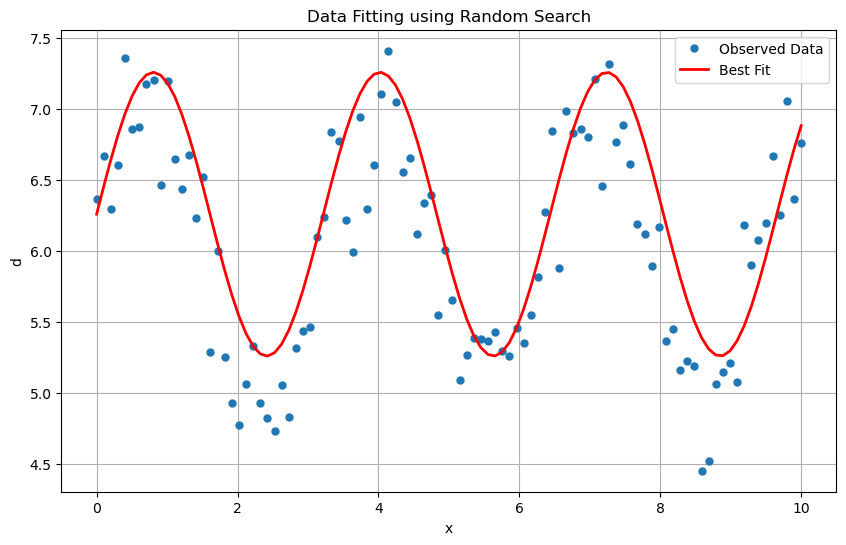

In [12]:
import numpy as np
N_iter = 1000;
m1min = 0.0;
m1max = 10.0;
m2min = 0.0;
m2max = 10.0;
w0 = 1.0;
sd2 = 0.1;
x = np.linspace(0,10,100);
gda_cvec = lambda m1,m2: np.array([m1,m2]);
dobs = np.sin(w0*2.0*x) + 2.0*3.0 + np.random.normal(loc=0.0,scale=np.sqrt(sd2),size=x.shape);
E0 = np.inf;
# true model parameters
for myiter in range(1,N_iter+1):
    # randomly select trial solution
    m1trial = np.random.uniform(low=m1min,high=m1max);
    m2trial = np.random.uniform(low=m2min,high=m2max);
    mtrial = gda_cvec( m1trial, m2trial );
    # predict data
    dtrial = np.sin(w0*m1trial*x) + m1trial*m2trial;
    # prediction error
    etrial = dobs-dtrial;
    Etrial = np.matmul(etrial.T,etrial)/sd2;
    # accept trial solution if error decreases
    if( Etrial<E0 ):
        # reset best-solution so far to this one
        E0=Etrial;
        m0 = mtrial;

#Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(x, dobs, 'o', label='Observed Data', markersize=5)
plt.plot(x, np.sin(w0*m0[0]*x) + m0[0]*m0[1], 'r-', label='Best Fit', linewidth=2)
plt.xlabel('x')
plt.ylabel('d')
plt.title('Data Fitting using Random Search')
plt.legend()
plt.grid()
plt.show()